# Tarea 1: el retrato de tu comuna

**INF-396 Introducción a la Ciencia de Datos** · Universidad Técnica Federico Santa María

| | |
|---|---|
| **Integrante 1** | Gabriel Delgado Rodriguez |
| **Comuna** | Maipu |
| **Comuna de contraste** | Ñuñoa |

**Antes de empezar**

1. El archivo se entrega con el nombre `tarea1_apellido1_apellido2.ipynb`.
2. El notebook debe correr **de principio a fin** en el entorno del curso
   (`uv sync`), leyendo los datos desde `datos/eod_stgo/`.
3. Cada ítem tiene tres partes: las instrucciones, una o más celdas de código,
   y una celda de **Interpretación** donde va su respuesta. Un resultado
   correcto sin interpretación no otorga el puntaje completo.

**Regla transversal de la tarea**

Toda cifra que hable de la población debe estar **ponderada por el factor de
expansión que corresponde a la unidad analizada**, usando como universo mínimo el
**día laboral de temporada normal**: `Factor` para hogares,
`Factor_LaboralNormal` para personas y `FactorLaboralNormal` para viajes (los dos
últimos difieren solo en un guion bajo). Si deciden ampliar el universo (fin de
semana, temporada estival), deben declararlo y usar los factores correspondientes.
Una cifra muestral presentada como poblacional, o una cifra que no declara su
universo, descuenta en el ítem.

## 0. Configuración

Esta celda deja listo lo que usarán en toda la tarea: las tres tablas
principales, la edad y el universo de día laboral. **Completen su comuna y
ejecútenla antes que todo lo demás.** Los nombres de comuna vienen en mayúsculas
y sin tildes (por ejemplo `"ESTACION CENTRAL"`).

Pandas no trae cuantiles ponderados: implementarlos es parte de la tarea.

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RUTA = "../cienciadatos/datos/eod_stgo/" #modifique la ruta ver

MI_COMUNA = "MAIPU"        # en mayusculas, como en Hogares.csv
COMUNA_CONTRASTE = "ÑUÑOA"

hogares = pd.read_csv(RUTA + "Hogares.csv", sep=";", decimal=",", low_memory=False)
personas = pd.read_csv(RUTA + "personas.csv", sep=";", decimal=",", low_memory=False)
viajes = pd.read_csv(RUTA + "viajes.csv", sep=";", decimal=",", low_memory=False)

# La encuesta registra el anio de nacimiento; la edad se calcula al 2013.
personas["Edad"] = 2013 - personas["AnoNac"]

# Universo minimo de la tarea: dia laboral de temporada normal.
# El factor viene vacio (NaN) para quienes no pertenecen a ese universo
# (encuestados de fin de semana y de temporada estival): el filtro los excluye.
personas_lab = personas.dropna(subset=["Factor_LaboralNormal"])
viajes_lab = viajes.dropna(subset=["FactorLaboralNormal"])


print(f"hogares: {len(hogares):,} | personas: {len(personas):,} | viajes: {len(viajes):,}")
print(f"universo laboral: {len(personas_lab):,} personas, {len(viajes_lab):,} viajes")


hogares: 18,264 | personas: 60,054 | viajes: 113,591
universo laboral: 37,326 personas, 78,820 viajes


## Parte 1. Retrato numérico (25 puntos)

### 1. La muestra y a quién representa (5 pts)

**Instrucciones**

Reporten cuatro cifras para su comuna: cuántos hogares y cuántas personas fueron
encuestados, y a cuántos hogares y personas representan según los factores de
expansión.

En la interpretación, expliquen en una frase por qué "encuestados" y
"representados" responden preguntas distintas.

In [61]:
# Su código (agreguen las celdas que necesiten)
hogaresMaipu = hogares[hogares["Comuna"] == MI_COMUNA]
hogaresNunoa = hogares[hogares["Comuna"] == COMUNA_CONTRASTE]
len(hogaresMaipu), round(hogaresMaipu["Factor"].sum()), len(hogaresNunoa), round(hogaresNunoa["Factor"].sum())

(1466, 153246, 603, 76526)

In [62]:
personasMaipu = pd.merge(hogaresMaipu, personas_lab, on="Hogar", how="left")
personasNunoa = pd.merge(hogaresNunoa, personas_lab, on="Hogar", how="left")
len(personasMaipu), round(personasMaipu["Factor_LaboralNormal"].sum()), len(personasNunoa), round(personasNunoa["Factor_LaboralNormal"].sum())

(3811, 516375, 1366, 211265)

###  Cifras Muestrales y Expandidas

| Comuna | Hogares Encuestados (Muestra) | Hogares Representados (Expandido) | Personas Encuestadas (Muestra) | Personas Representadas (Expandido) |
| :--- | :---: | :---: | :---: | :---: |
| **Maipú** | 1466 | 153246 | 3811 | 516375 |
| **Ñuñoa** | 603 | 76526 | 1366 | 211265 |

**Interpretación:**  Los encuestados son unidades registradas por la encuesta, los respresentados se traduce en toda la poblacion que representa la respuesta del encuestado, traduciendose en que ese ciudadano se amplifica en muchas personas con la misma situacion

### 2. Composición (6 pts)

**Instrucciones**

Describan la composición de su comuna comparada con la del Gran Santiago:
la distribución por sexo (la proporción ponderada de cada categoría) y la edad
(mediana y percentiles 25 y 75 ponderados), para las dos unidades. La
ponderación usa el factor de la persona, dentro del universo que declararon al
inicio; si trabajan con el mínimo de día laboral, la celda de configuración ya
les deja `personas_lab` filtrado.

En la interpretación, expliquen en qué se parece y en qué difiere la composición
de su comuna respecto de la ciudad.

In [63]:
# Su código (agreguen las celdas que necesiten)
pondHMaipu= personasMaipu[personasMaipu["Sexo"] == 1]["Factor_LaboralNormal"].sum()
pondMMaipu = personasMaipu[personasMaipu["Sexo"] == 2]["Factor_LaboralNormal"].sum()
pondH = personas[personas["Sexo"] == 1]["Factor_LaboralNormal"].sum()
pondM = personas[personas["Sexo"] == 2]["Factor_LaboralNormal"].sum()
pondPMaipu = personasMaipu["Factor_LaboralNormal"].sum()
pondP = personas["Factor_LaboralNormal"].sum()
round(pondHMaipu), round(pondMMaipu),round(pondH), round(pondM)

(245066, 271309, 3227373, 3424362)

In [64]:
round(pondPMaipu), round(pondP)

(516375, 6651735)

In [65]:
porcHMaipu = (pondHMaipu / pondPMaipu)*100
porcMMaipu = (pondMMaipu / pondPMaipu)*100
porcH = (pondH / pondP)*100
porcM = (pondM / pondP)*100
porcHMaipu, porcMMaipu, porcH, porcM

(np.float64(47.458935800504285),
 np.float64(52.541064199495715),
 np.float64(48.51927170542352),
 np.float64(51.48072829457647))

In [66]:
(pondHMaipu/pondH)*100, (pondMMaipu/pondM)*100

(np.float64(7.593361126661111), np.float64(7.922906216060999))

En Maipu la representacion de hombres corresponde a un aproximado de 47% mientras que las mujeres corresponde a la mayoria con un 52%, en cambio en Santiago, la representacion de hombres asciende casi al 49% aumentando en mas de 1 punto. A nivel Santiago, los hombres de Maipu representan en 7.5% meintas que la representacion de mujeres aporta casi un 8% de las mujeres de la comuna

In [67]:
#funcion aux para calcular cuantil ponderado
def cuantil_ponderado(valores, pesos, cuantiles):
    """Cuantiles de una variable con pesos de muestreo."""
    d = pd.DataFrame({"v": valores, "w": pesos}).dropna().sort_values("v")
    acumulada = d["w"].cumsum() / d["w"].sum()
    return [float(d.loc[(acumulada >= q).idxmax(), "v"]) for q in np.atleast_1d(cuantiles)]

In [68]:
cuantil_ponderado(personasMaipu["Edad"], personasMaipu["Factor_LaboralNormal"], [0.25, 0.5, 0.75]), cuantil_ponderado(personas["Edad"], personas["Factor_LaboralNormal"], [0.25, 0.5, 0.75])

([19.0, 34.0, 53.0], [19.0, 35.0, 54.0])

**Interpretación:** Tanto a nivel comunal como regional las mujeres representan la mayor parte de la poblacion, aunque a nivel maipu las mujeres tienen un mayor porcentaje de poblacion representativa comparandola con el Gran Santiago en mas de de 1 punto. En cuanto a edad ambos tienen un cuantie 25 de 19  años y una diferencia de 1 año en el cuantl 75 con 51 y 52 años a nivel comunal y regional y en la mediana con 34 y 35 años respectivamente, indicando que en Maipu la poblacion es ligeramente mas joven en el tramo medio y medio-alto.

### 3. Ingresos (7 pts)

**Instrucciones**

Calculen tres medidas del ingreso de los hogares de su comuna, ponderadas por
`Factor`: la media, la mediana y la media truncada al 10%. Para la truncada,
excluyan el 10% más bajo y el 10% más alto del ingreso (los percentiles
ponderados 10 y 90 definen los cortes) y recalculen la media ponderada con los
hogares restantes. Calculen las mismas tres medidas para la ciudad completa,
como referencia.

En la interpretación, decidan cuál de las tres medidas reportarían como "el
ingreso de la comuna" y justifíquenla a partir de la forma de la distribución de
su comuna, no como regla de memoria.

In [69]:
# Su código (agreguen las celdas que necesiten)
mediaMSueldos = np.average(hogaresMaipu["IngresoHogar"], weights=hogaresMaipu["Factor"])
mediaSueldos = np.average(hogares["IngresoHogar"], weights=hogares["Factor"])
round(mediaMSueldos), round(mediaSueldos)


(595384, 729898)

In [70]:
medianaMSueldos = cuantil_ponderado(hogaresMaipu["IngresoHogar"], hogaresMaipu["Factor"], [0.5])
medianaSueldos = cuantil_ponderado(hogares["IngresoHogar"], hogares["Factor"], [0.5])
(round(medianaMSueldos[0])), round(medianaSueldos[0])

(500000, 520000)

In [71]:
M10M, M90M = cuantil_ponderado(hogaresMaipu["IngresoHogar"], hogaresMaipu["Factor"], [0.1, 0.9])
truncadaMaipu = hogaresMaipu[(hogaresMaipu["IngresoHogar"] < M90M) & (hogaresMaipu["IngresoHogar"] > M10M)]
M10, M90 = cuantil_ponderado(hogares["IngresoHogar"], hogares["Factor"], [0.1, 0.9])
truncadaSantiago = hogares[(hogares["IngresoHogar"] < M90) & (hogares["IngresoHogar"] > M10)]
mediaTMSueldos = np.average(truncadaMaipu["IngresoHogar"], weights=truncadaMaipu["Factor"])
mediaTSueldos = np.average(truncadaSantiago["IngresoHogar"], weights=truncadaSantiago["Factor"])
round(mediaTMSueldos), round(mediaTSueldos)

(533286, 593081)

**Interpretación:** En este caso particular se considerara que los valores que se van a reportar como ingresos de la comuna seran 500000 y 520000 para Maipu y el Gran Santiago respectivamente, esto debido a que al comparar las medias, medianas y medias truncadas, estas ultimas no se alejan tanto de las medianas respectivas pero sí del las medias estandar, lo que implica una presencia no menor de outliers pero dada la naturaleza del origen de los datos se considera una postura mas conservadora con respecto a las metricas permite reflejar la relidad que los datos pueden mostrar

### 4. El parque vehicular (7 pts)

**Instrucciones**

Incorporen `Vehiculo.csv` al retrato. La tabla tiene una fila por cada vehículo
de un hogar y está codificada en latin-1, así que deben leerla con
`encoding="latin-1"`.

Como una fila de esta tabla es un vehículo y no un hogar, decidan y justifiquen
qué factor de expansión le corresponde.

Caractericen el parque vehicular de su comuna contra el de la ciudad, por
ejemplo con la antigüedad de los vehículos al 2012, el año de la encuesta
(mediana ponderada), y con la
proporción ponderada que tiene sello verde. La columna `SelloVerde` viene
codificada y su catálogo está en `tablas_parametros/`. Documenten las llaves que
usaron y verifiquen el merge.

En la interpretación, digan qué muestra el parque vehicular de su comuna
comparado con el de la ciudad.

In [72]:
# Su código (agreguen las celdas que necesiten)
vehiculos = pd.read_csv(RUTA + "Vehiculo.csv", sep=";", decimal=",", low_memory=False, encoding="latin-1")
vehiculosConFactor = pd.merge(vehiculos, hogares[['Hogar', 'Comuna', 'Factor']], on='Hogar', how='inner')
vehiculosConFactorMaipu = vehiculosConFactor[vehiculosConFactor['Comuna'] == MI_COMUNA]


Se decide usar el factor de los hogares y no el de persona debido a que los registros vehiculares estan asociados a los hogares que pertenecen los vehiculos, entonces al momento de amplificar por el factor se esta  escalando los vehiculos por hogar y no por personas, asi que el factor correspondiente es el que esta asociado al hogar

In [73]:
totalVFactorMaipu = vehiculosConFactorMaipu["Factor"].sum()
totalVFactor = vehiculosConFactor["Factor"].sum()

vehiculosEdadMaipu = vehiculosConFactorMaipu[
    vehiculosConFactorMaipu["EdadVehiculo"] != 9
]

vehiculosEdad = vehiculosConFactor[
    vehiculosConFactor["EdadVehiculo"] != 9
]

medianaEVehiculosMaipu = cuantil_ponderado(
    vehiculosEdadMaipu["EdadVehiculo"],
    vehiculosEdadMaipu["Factor"],
    [0.5]
)

medianaEVehiculos = cuantil_ponderado(
    vehiculosEdad["EdadVehiculo"],
    vehiculosEdad["Factor"],
    [0.5]
)

porcentajeSVMaipu = (
    vehiculosConFactorMaipu[
        vehiculosConFactorMaipu["SelloVerde"] == 1
    ]["Factor"].sum()
    / totalVFactorMaipu
)

porcentajeSV = (
    vehiculosConFactor[
        vehiculosConFactor["SelloVerde"] == 1
    ]["Factor"].sum()
    / totalVFactor
)

medianaEVehiculosMaipu[0], medianaEVehiculos[0], round(porcentajeSVMaipu, 2), round(porcentajeSV, 2)

(2.0, 2.0, np.float64(0.19), np.float64(0.25))

**Interpretación:** La mediana representiva del parque vehicular de ambas comunas es la misma indicando que tienen una composicion similar con una edad de entre 3 y 5 años; en cambio a nivel comuna existe una diferencia de 6 puntos por debajo comparado con el Gran Santiago en la cantidad autos representados con Sello Verde.

## Parte 2. Retrato gráfico y asociaciones (30 puntos)

Todos los gráficos de esta parte deben llevar título y ejes rotulados con sus unidades.

Cuando un ítem habla de **los viajes de una comuna**, se refiere a los viajes con
**origen** en ella (`ComunaOrigen`); pueden además presentar los destinos si
aportan al retrato. `ComunaOrigen` viene codificada: se traduce con
`tablas_parametros/Comuna.csv` (separado por comas y en latin-1).

### 5. Distribución de ingresos (8 pts)

**Instrucciones**

Construyan un solo gráfico que permita comparar la distribución completa del
ingreso de los hogares de su comuna contra la del Gran Santiago; comparar dos
promedios no basta. El gráfico debe estar ponderado por `Factor`, y como la
comuna y la ciudad tienen tamaños muy distintos, las dos distribuciones deben
quedar en una escala comparable.

En la interpretación, justifiquen el tipo de gráfico elegido, digan qué
alternativa descartaron y por qué, y lean la comparación: ¿dónde se concentra su
comuna respecto de la ciudad?

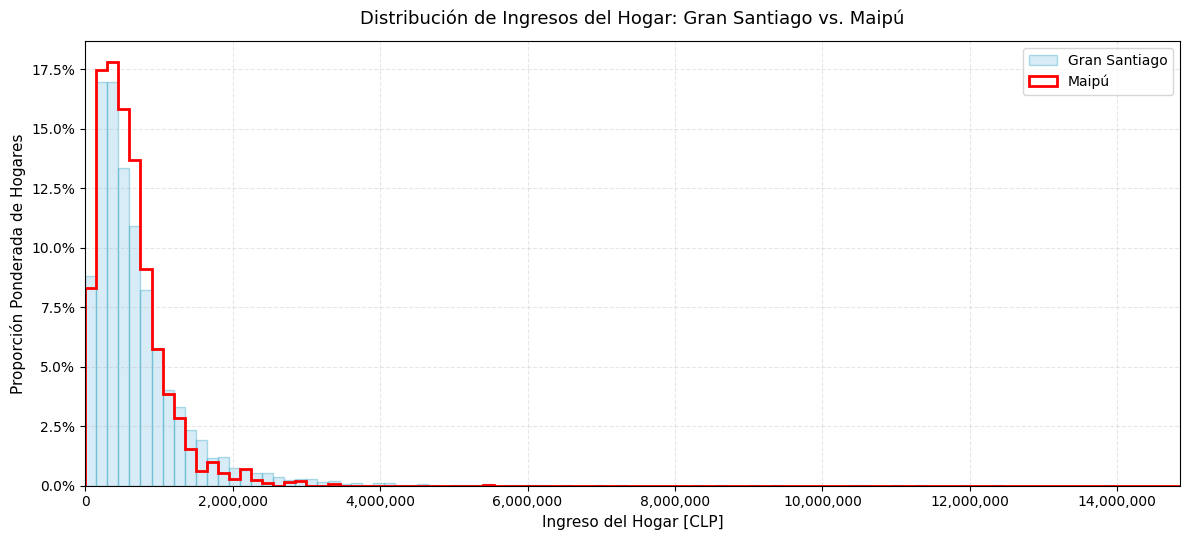

In [74]:
from matplotlib.ticker import FuncFormatter
import numpy as np

# 1. Limpiar nulos
clean_stgo = hogares[['IngresoHogar', 'Factor']].dropna()
clean_maipu = hogaresMaipu[['IngresoHogar', 'Factor']].dropna()

# 2. Bins uniformes incluyendo toda la cola
ancho_bin = 150_000

max_observado = max(
    clean_stgo['IngresoHogar'].max(),
    clean_maipu['IngresoHogar'].max()
)

# Redondear hacia arriba al múltiplo de ancho_bin
max_ingreso = np.ceil(max_observado / ancho_bin) * ancho_bin

bins = np.arange(0, max_ingreso + ancho_bin, ancho_bin)

# 3. Ponderaciones
weights_stgo = clean_stgo['Factor'] / clean_stgo['Factor'].sum()
weights_maipu = clean_maipu['Factor'] / clean_maipu['Factor'].sum()

plt.figure(figsize=(12, 5.5))

# Gran Santiago
plt.hist(
    clean_stgo['IngresoHogar'],
    bins=bins,
    weights=weights_stgo,
    color='#8ecae6',
    alpha=0.35,
    label='Gran Santiago',
    edgecolor='#219ebc'
)

# Maipú
plt.hist(
    clean_maipu['IngresoHogar'],
    bins=bins,
    weights=weights_maipu,
    color='red',
    histtype='step',
    linewidth=2,
    label='Maipú'
)

plt.title(
    'Distribución de Ingresos del Hogar: Gran Santiago vs. Maipú',
    fontsize=13,
    pad=12
)
plt.xlabel('Ingreso del Hogar [CLP]', fontsize=11)
plt.ylabel('Proporción Ponderada de Hogares', fontsize=11)

# Ahora llega hasta el máximo real de los datos
plt.xlim(0, max_ingreso)

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{int(x):,}')
)
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda y, _: f'{y * 100:.1f}%')
)

plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(frameon=True, fontsize=10)

plt.tight_layout()
plt.show()

**Interpretación:** Se eligió el histograma clasico por sobre bloxplot, KDE y el ECDF  debido a que se considera mas ilustrativa, sencillo y facil de leer a simple vista; ademas de evidenciar de forma sencilla donde estan mas concentrados los datos y en la diferencia entre Maipu y el Gran Santiago.

### 6. La comuna de contraste (8 pts)

**Instrucciones**

Elijan una comuna con un perfil de movilidad distinto al de la suya y
justifiquen la elección con datos; una cifra basta.

Calculen el reparto modal ponderado de las tres unidades: su comuna, la de
contraste y el Gran Santiago. El modo de cada viaje está en `ViajesDifusion.csv`
(llave `Viaje`) y su catálogo en `tablas_parametros/ModoDifusion.csv`; un viaje
pertenece a la comuna de su origen y el peso es `FactorLaboralNormal`.

Muestren las tres unidades en una sola figura.

En la interpretación, lean el contraste entre las tres unidades.

In [75]:
# Su código (agreguen las celdas que necesiten)
viajesDifusion = pd.read_csv(RUTA + "ViajesDifusion.csv", sep=";", decimal=",", low_memory=False, encoding="latin-1")
viajesCompleto_lab = pd.merge(viajes_lab, viajesDifusion, on="Viaje", how="left")

In [76]:
viajesCompletoMaipu_lab = viajesCompleto_lab[viajesCompleto_lab['ComunaOrigen'] == 94]
auto_maipu = (viajesCompletoMaipu_lab[viajesCompletoMaipu_lab['ComunaDestino'] == 94]['FactorLaboralNormal'].sum() / viajesCompletoMaipu_lab['FactorLaboralNormal'].sum()) * 100

viajesCompletoNunoa_lab = viajesCompleto_lab[viajesCompleto_lab['ComunaOrigen'] == 91]
auto_nunoa = (viajesCompletoNunoa_lab[viajesCompletoNunoa_lab['ComunaDestino'] == 91]['FactorLaboralNormal'].sum() / viajesCompletoNunoa_lab['FactorLaboralNormal'].sum()) * 100

print(f"Autocontención (viajes internos) Maipú: {auto_maipu:.1f}%")
print(f"Autocontención (viajes internos) Ñuñoa: {auto_nunoa:.1f}%")

Autocontención (viajes internos) Maipú: 67.1%
Autocontención (viajes internos) Ñuñoa: 41.5%


Se elige la comuna de Ñuñoa como contraste debido al rol geográfico y funcional opuesto que tienen ambas comunas. Maipú, al ser más periférica, presenta una alta tasa de autocontención del 67,1% (generando su propia dinámica local de viajes), mientras que Ñuñoa, al ser un punto céntrico e integrado a otras comunas, solo retiene el 41,5% de sus viajes, lo que anticipa patrones de movilidad y reparto modal claramente distintos.

In [77]:
repartoCompleto = (
    viajesCompleto_lab.groupby('ModoDifusion')['FactorLaboralNormal']
    .sum()
    .div(viajesCompleto_lab['FactorLaboralNormal'].sum())
    .mul(100)
    .sort_values(ascending=False)
    .round(2)
)

repartoCompletoMaipu = (
    viajesCompletoMaipu_lab.groupby('ModoDifusion')['FactorLaboralNormal']
    .sum()
    .div(viajesCompletoMaipu_lab['FactorLaboralNormal'].sum())
    .mul(100)
    .sort_values(ascending=False)
    .round(2)
)

repartoCompletoNunoa = (
    viajesCompletoNunoa_lab.groupby('ModoDifusion')['FactorLaboralNormal']
    .sum()
    .div(viajesCompletoNunoa_lab['FactorLaboralNormal'].sum())
    .mul(100)
    .sort_values(ascending=False)
    .round(2)
)

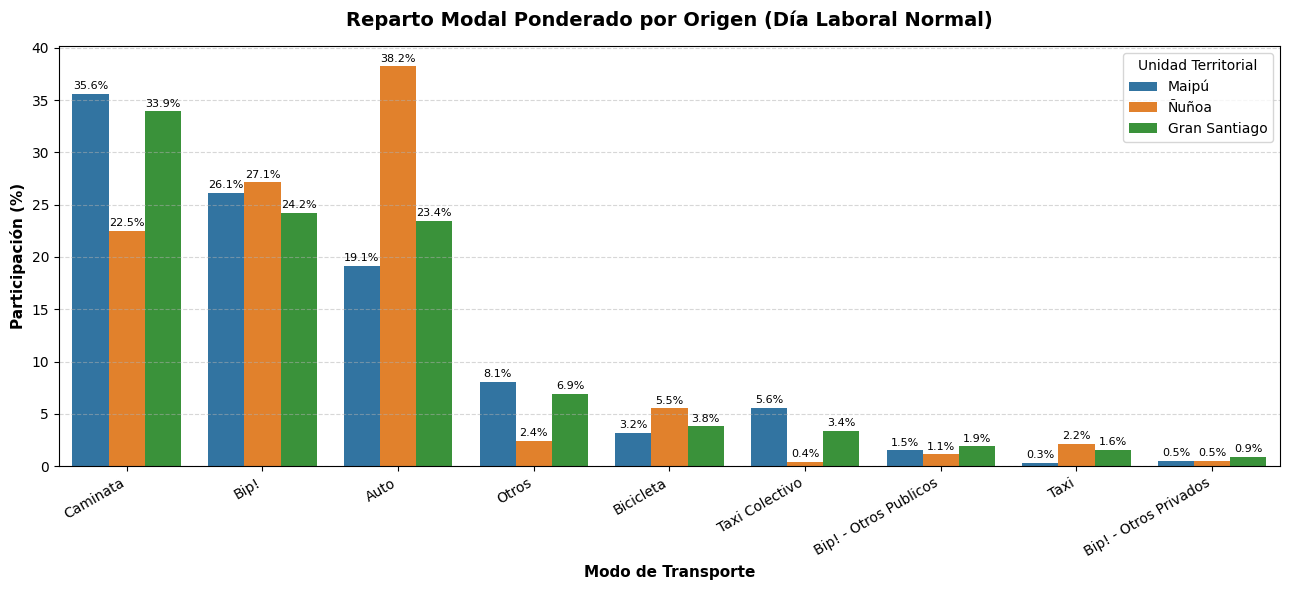

In [78]:
import seaborn as sns
dicc_modos = {
    1: 'Auto',
    2: 'Bip!',
    3: 'Taxi Colectivo',
    4: 'Taxi',
    5: 'Bip! - Otros Publicos',
    6: 'Bip! - Otros Privados',
    7: 'Otros',
    8: 'Caminata',
    9: 'Bicicleta'
}

# 1. Asegurar la reasignación de los nombres con el diccionario
rep_stgo = repartoCompleto.rename(index=dicc_modos).reset_index()
rep_stgo.columns = ['Modo', 'Porcentaje']
rep_stgo['Unidad'] = 'Gran Santiago'

rep_maipu = repartoCompletoMaipu.rename(index=dicc_modos).reset_index()
rep_maipu.columns = ['Modo', 'Porcentaje']
rep_maipu['Unidad'] = 'Maipú'

rep_nunoa = repartoCompletoNunoa.rename(index=dicc_modos).reset_index()
rep_nunoa.columns = ['Modo', 'Porcentaje']
rep_nunoa['Unidad'] = 'Ñuñoa'

# 2. Consolidar en un solo DataFrame para graficar
df_plot = pd.concat([rep_maipu, rep_nunoa, rep_stgo], ignore_index=True)

# 3. Ordenar las categorías en el eje X según el orden general del Gran Santiago
orden_modos = rep_stgo.sort_values('Porcentaje', ascending=False)['Modo'].tolist()

# 4. Graficar en una sola figura
plt.figure(figsize=(13, 6))
ax = sns.barplot(
    data=df_plot,
    x='Modo',
    y='Porcentaje',
    hue='Unidad',
    order=orden_modos,
    palette=['#1f77b4', '#ff7f0e', '#2ca02c']
)

# Estética y etiquetas
plt.title('Reparto Modal Ponderado por Origen (Día Laboral Normal)', fontsize=14, weight='bold', pad=15)
plt.xlabel('Modo de Transporte', fontsize=11, weight='bold')
plt.ylabel('Participación (%)', fontsize=11, weight='bold')
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Unidad Territorial', frameon=True)

# mostrar valores encima de las barras
for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f'{h:.1f}%', 
                    (p.get_x() + p.get_width() / 2., h),
                    ha='center', va='bottom', fontsize=8, rotation=0, xytext=(0, 2),
                    textcoords='offset points')

plt.tight_layout()
plt.show()

**Interpretación:** Tanto Maipu como el Gran Santiago tienen comportamientos similares en el modo de transporte, lo cual indica que la mayor parte de los viajes vienen asociados a ubicaciones perifericas; en cambio una comuna con una ubicacion estrategica como lo es Ñuñoa muestra modos de viaje distintos que pueden estar asociados a la cercania de sus destinos y la capacidad adquisitiva de las personas de ese sector.

### 7. Ingreso y transporte público (8 pts)

**Instrucciones**

Para todas las comunas del Gran Santiago calculen dos series: el ingreso medio
ponderado de los hogares (`IngresoHogar` con `Factor`) y la proporción ponderada
de viajes en transporte público. Decidan qué modos de `ModoDifusion` cuentan
como transporte público y declárenlo; el peso de los viajes es
`FactorLaboralNormal`.

Grafiquen una serie contra la otra, con cada comuna como un punto, destacando la
suya y la de contraste. Calculen las correlaciones de Pearson y de Spearman
entre ambas series.

En la interpretación: ¿qué indica la diferencia entre los dos coeficientes?
¿Qué comunas se apartan del patrón general, y dónde queda la suya?

Se considerarán como transporte público los modos _Bip!_, _Taxi colectivo_ y _Bip! - Otros Publicos_

Número de comunas analizadas: 38
Pearson:  -0.089 (p = 0.5947)
Spearman: 0.120 (p = 0.4737)


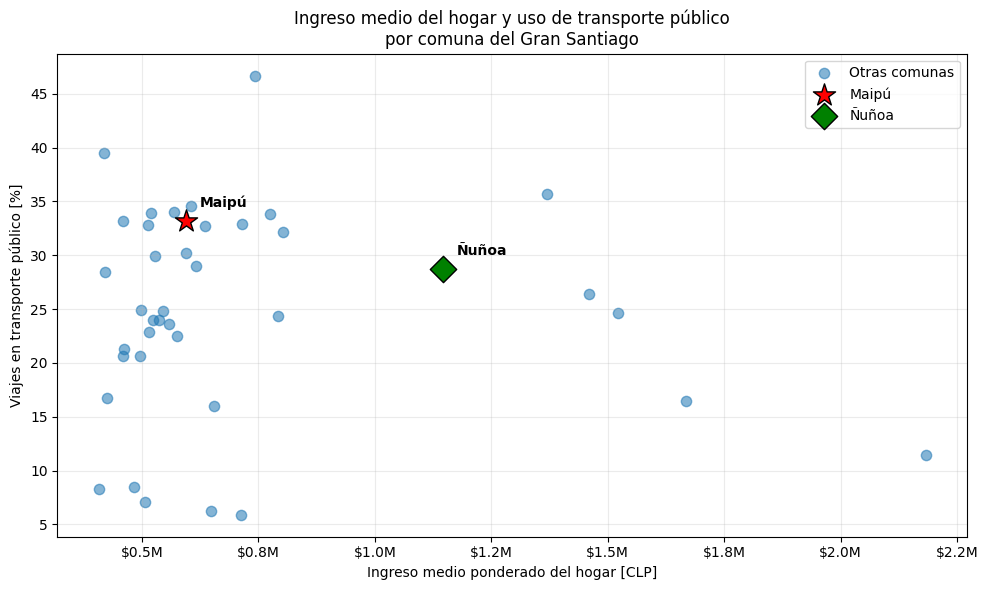

In [79]:
# Su código (agreguen las celdas que necesiten)
import scipy.stats as stats

modos_tp = [2, 3, 5]


# ==============================================================================
# 1. PROPORCIÓN PONDERADA DE VIAJES EN TRANSPORTE PÚBLICO POR COMUNA
# ==============================================================================

v = viajesCompleto_lab[
    ['ComunaOrigen', 'ModoDifusion', 'FactorLaboralNormal']
].dropna().copy()

v['FactorTP'] = (
    v['FactorLaboralNormal']
    * v['ModoDifusion'].isin(modos_tp)
)

tp = (
    v.groupby('ComunaOrigen')
     .agg(
         total=('FactorLaboralNormal', 'sum'),
         publico=('FactorTP', 'sum')
     )
     .reset_index()
)

tp['Prop_TP'] = 100 * tp['publico'] / tp['total']

tp['CodigoComuna'] = pd.to_numeric(
    tp['ComunaOrigen'],
    errors='coerce'
)

tp = tp.dropna(subset=['CodigoComuna'])
tp['CodigoComuna'] = tp['CodigoComuna'].astype(int)


# ==============================================================================
# 2. INGRESO MEDIO PONDERADO POR COMUNA
# ==============================================================================

h = hogares[
    ['Comuna', 'IngresoHogar', 'Factor']
].dropna().copy()

h['IngresoPond'] = h['IngresoHogar'] * h['Factor']

ingreso = (
    h.groupby('Comuna')
     .agg(
         ingreso_pond=('IngresoPond', 'sum'),
         factor=('Factor', 'sum')
     )
     .reset_index()
)

ingreso['IngresoMedio'] = (
    ingreso['ingreso_pond'] / ingreso['factor']
)


# ==============================================================================
# 3. TRADUCIR NOMBRE DE COMUNA A CÓDIGO
# ==============================================================================

tabla_comunas = pd.read_csv(
    RUTA + 'tablas_parametros/Comuna.csv',
    sep=',',
    encoding='latin-1'
)


def normalizar(serie):
    return (
        serie.astype(str)
             .str.strip()
             .str.upper()
             .str.normalize('NFKD')
             .str.encode('ascii', errors='ignore')
             .str.decode('ascii')
    )


ingreso['nombre_norm'] = normalizar(ingreso['Comuna'])

# Detectar columna con nombres de comuna
nombres_hogares = set(ingreso['nombre_norm'])

col_nombre = max(
    tabla_comunas.columns,
    key=lambda c: len(
        set(normalizar(tabla_comunas[c])) & nombres_hogares
    )
)


# Detectar columna con códigos de comuna
codigos_origen = set(tp['CodigoComuna'])


def coincidencias_codigo(columna):
    valores = pd.to_numeric(
        tabla_comunas[columna],
        errors='coerce'
    ).dropna().astype(int)

    return len(set(valores) & codigos_origen)


col_codigo = max(
    tabla_comunas.columns,
    key=coincidencias_codigo
)


mapa_comunas = tabla_comunas[
    [col_nombre, col_codigo]
].copy()

mapa_comunas['nombre_norm'] = normalizar(
    mapa_comunas[col_nombre]
)

mapa_comunas['CodigoComuna'] = pd.to_numeric(
    mapa_comunas[col_codigo],
    errors='coerce'
)

mapa_comunas = (
    mapa_comunas
    .dropna(subset=['CodigoComuna'])
    .drop_duplicates(subset='nombre_norm')
)

mapa_comunas['CodigoComuna'] = (
    mapa_comunas['CodigoComuna'].astype(int)
)


# ==============================================================================
# 4. UNIR INGRESO Y TRANSPORTE PÚBLICO
# ==============================================================================

df_analisis = (
    ingreso
    .merge(
        mapa_comunas[['nombre_norm', 'CodigoComuna']],
        on='nombre_norm',
        how='inner'
    )
    .merge(
        tp[['CodigoComuna', 'Prop_TP']],
        on='CodigoComuna',
        how='inner'
    )
)

df_analisis = df_analisis.dropna(
    subset=['IngresoMedio', 'Prop_TP']
)


# ==============================================================================
# 5. CORRELACIONES
# ==============================================================================

r_pearson, p_pearson = stats.pearsonr(
    df_analisis['IngresoMedio'],
    df_analisis['Prop_TP']
)

r_spearman, p_spearman = stats.spearmanr(
    df_analisis['IngresoMedio'],
    df_analisis['Prop_TP']
)

print(f"Número de comunas analizadas: {len(df_analisis)}")
print(f"Pearson:  {r_pearson:.3f} (p = {p_pearson:.4f})")
print(f"Spearman: {r_spearman:.3f} (p = {p_spearman:.4f})")


# ==============================================================================
# 6. VALORES DE MAIPÚ Y ÑUÑOA
# ==============================================================================

# Maipú:
# ya calculaste su ingreso medio ponderado en la sección 3
ingreso_maipu = mediaMSueldos

# Ñuñoa:
# este valor no se había calculado anteriormente
ingreso_nunoa = np.average(
    hogaresNunoa['IngresoHogar'],
    weights=hogaresNunoa['Factor']
)

# El reparto modal ponderado de ambas comunas ya se calculó en la sección 6.
# Solo sumamos los modos que declaramos como transporte público.
tp_maipu = repartoCompletoMaipu.reindex(
    modos_tp,
    fill_value=0
).sum()

tp_nunoa = repartoCompletoNunoa.reindex(
    modos_tp,
    fill_value=0
).sum()

# ==============================================================================
# 7. GRÁFICO
# ==============================================================================

fig, ax = plt.subplots(figsize=(10, 6))


# Todas las comunas
ax.scatter(
    df_analisis['IngresoMedio'],
    df_analisis['Prop_TP'],
    alpha=0.55,
    s=55,
    label='Otras comunas'
)


# Maipú
ax.scatter(
    ingreso_maipu,
    tp_maipu,
    s=280,
    marker='*',
    color='red',
    edgecolor='black',
    linewidth=1,
    label='Maipú',
    zorder=10
)


# Ñuñoa
ax.scatter(
    ingreso_nunoa,
    tp_nunoa,
    s=180,
    marker='D',
    color='green',
    edgecolor='black',
    linewidth=1,
    label='Ñuñoa',
    zorder=10
)


# Etiqueta Maipú
ax.annotate(
    'Maipú',
    (ingreso_maipu, tp_maipu),
    xytext=(10, 10),
    textcoords='offset points',
    fontsize=10,
    fontweight='bold'
)


# Etiqueta Ñuñoa
ax.annotate(
    'Ñuñoa',
    (ingreso_nunoa, tp_nunoa),
    xytext=(10, 10),
    textcoords='offset points',
    fontsize=10,
    fontweight='bold'
)


# Título y ejes
ax.set_title(
    'Ingreso medio del hogar y uso de transporte público\n'
    'por comuna del Gran Santiago'
)

ax.set_xlabel(
    'Ingreso medio ponderado del hogar [CLP]'
)

ax.set_ylabel(
    'Viajes en transporte público [%]'
)


# Formato del eje de ingresos
ax.xaxis.set_major_formatter(
    FuncFormatter(
        lambda x, _: f'${x / 1_000_000:.1f}M'
    )
)

ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

**Interpretación:** El coeficiente de Pearson tiene un valor negativo representando que hay una relacion negativa entre el ingreso y el porcentaje de viajes en transporte publico, indicando que a nivel Santiago entre mas ingreso menos se usa el trnasporte publico pero debido a que el coeficiente tuvo un valor de -0.089 no se puede respaldar la relacion lineal dicha. Con Spearman dio signo positivo indicando que hay una relacion monotona creciente entre las variables pero al tener un valor de 0.120, siendo muy cercano a 0, la relacion creciente no es fiable para este par de variables.

Ñuñoa marca el inicio de las comunas que se aleja de la nube de datos de la izquierda y estan aquellas qie tienen el mayor ingreso medio. La comuna de Maipú se encuentra en el medio de la nube de datos de la izquierda con un ingreso medio cecano al de Santiago.

### 8. Un hallazgo propio (6 pts)

**Instrucciones**

Agreguen un gráfico a elección que muestre algo del retrato que los ítems
anteriores no capturan, ponderado como todo lo demás. Se evalúa que el hallazgo
no sea trivial: que no repita lo ya visto ni muestre algo obvio.

En la interpretación, escriban la lectura del hallazgo en dos o tres líneas.

Categoria,Familiar/social,Recreativo,Total_finde,Pct_social,Pct_recreativo
ComunaDestino,,,,,
MAIPÚ,70.28,57.19,410.86,17.10,13.92
ÑUÑOA,18.08,52.71,314.27,5.75,16.77


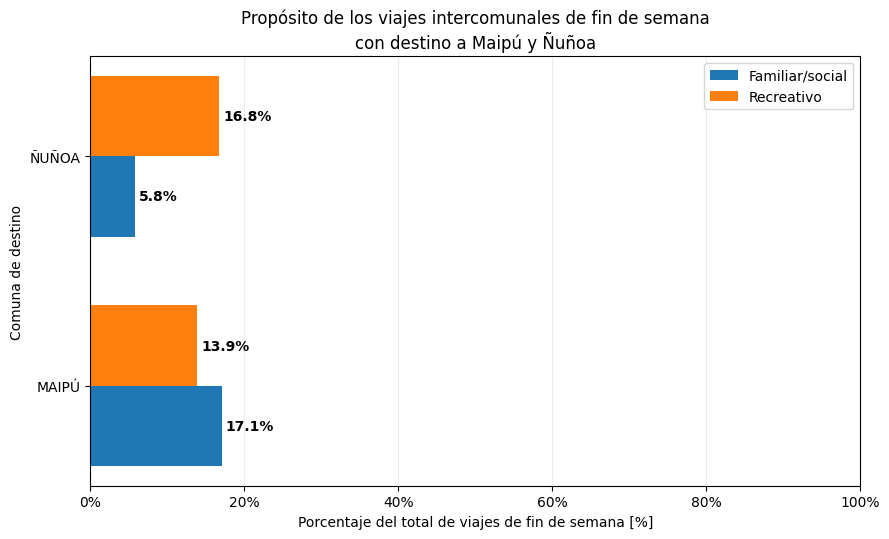

In [80]:
# Su código (agreguen las celdas que necesiten)

# Propósitos considerados
# 6  = Visitar a alguien
# 8  = Buscar o dejar a alguien
# 9  = Comer o tomar algo
# 11 = De compras
# 13 = Recreación

propositos_familiares = [6, 8]
propositos_recreativos = [9, 11, 13]


# ==============================================================================
# 1. VIAJES DE FIN DE SEMANA
# ==============================================================================

viajes_finde = viajes[
    [
        'ComunaOrigen',
        'ComunaDestino',
        'Proposito',
        'FactorSabadoNormal',
        'FactorDomingoNormal'
    ]
].copy()

# Unir sábado y domingo en un único ponderador
viajes_finde['FactorFinde'] = (
    viajes_finde['FactorSabadoNormal'].fillna(0)
    + viajes_finde['FactorDomingoNormal'].fillna(0)
)

# Solo viajes de fin de semana
viajes_finde = viajes_finde[
    viajes_finde['FactorFinde'] > 0
].copy()

# Eliminar observaciones sin información necesaria
viajes_finde = viajes_finde.dropna(
    subset=['ComunaOrigen', 'ComunaDestino', 'Proposito']
)

# Convertir códigos de comuna a numérico
viajes_finde['ComunaOrigen'] = pd.to_numeric(
    viajes_finde['ComunaOrigen'],
    errors='coerce'
)

viajes_finde['ComunaDestino'] = pd.to_numeric(
    viajes_finde['ComunaDestino'],
    errors='coerce'
)

viajes_finde = viajes_finde.dropna(
    subset=['ComunaOrigen', 'ComunaDestino']
)

viajes_finde['ComunaOrigen'] = (
    viajes_finde['ComunaOrigen'].astype(int)
)

viajes_finde['ComunaDestino'] = (
    viajes_finde['ComunaDestino'].astype(int)
)


# ==============================================================================
# 2. SOLO VIAJES INTERCOMUNALES
# ==============================================================================

viajes_finde = viajes_finde[
    viajes_finde['ComunaOrigen']
    != viajes_finde['ComunaDestino']
].copy()


# ==============================================================================
# 3. SOLO VIAJES CON DESTINO A MAIPÚ O ÑUÑOA
# ==============================================================================

# 94 = Maipú
# 91 = Ñuñoa

viajes_finde = viajes_finde[
    viajes_finde['ComunaDestino'].isin([94, 91])
].copy()


# ==============================================================================
# 4. TOTAL DE VIAJES DE FIN DE SEMANA HACIA CADA COMUNA
# ==============================================================================

# Este será el denominador:
# TODOS los viajes intercomunales de fin de semana,
# sin importar el propósito.

total_finde = (
    viajes_finde
    .groupby('ComunaDestino')['FactorFinde']
    .sum()
)


# ==============================================================================
# 5. CLASIFICAR PROPÓSITOS
# ==============================================================================

viajes_finde['Categoria'] = np.select(
    [
        viajes_finde['Proposito'].isin(propositos_familiares),
        viajes_finde['Proposito'].isin(propositos_recreativos)
    ],
    [
        'Familiar/social',
        'Recreativo'
    ],
    default='Otro'
)


# Nos quedamos con las dos categorías que queremos analizar
viajes_atraccion = viajes_finde[
    viajes_finde['Categoria'].isin(
        ['Familiar/social', 'Recreativo']
    )
].copy()


# ==============================================================================
# 6. SUMAR VIAJES PONDERADOS POR COMUNA Y CATEGORÍA
# ==============================================================================

comparacion = (
    viajes_atraccion
    .groupby(
        ['ComunaDestino', 'Categoria']
    )['FactorFinde']
    .sum()
    .unstack(fill_value=0)
)

# Asegurar ambas comunas
comparacion = comparacion.reindex(
    [94, 91],
    fill_value=0
)

# Asegurar ambas categorías
for categoria in ['Familiar/social', 'Recreativo']:
    if categoria not in comparacion.columns:
        comparacion[categoria] = 0


# ==============================================================================
# 7. AGREGAR TOTAL DE VIAJES DE FIN DE SEMANA
# ==============================================================================

comparacion['Total_finde'] = total_finde.reindex(
    comparacion.index,
    fill_value=0
)


# ==============================================================================
# 8. PORCENTAJES SOBRE EL TOTAL DE VIAJES DE FIN DE SEMANA
# ==============================================================================

comparacion['Pct_social'] = (
    100
    * comparacion['Familiar/social']
    / comparacion['Total_finde']
)

comparacion['Pct_recreativo'] = (
    100
    * comparacion['Recreativo']
    / comparacion['Total_finde']
)


# Cambiar códigos por nombres
comparacion = comparacion.rename(
    index={
        94: 'MAIPÚ',
        91: 'ÑUÑOA'
    }
)


# Mostrar resultados
display(
    comparacion[
        [
            'Familiar/social',
            'Recreativo',
            'Total_finde',
            'Pct_social',
            'Pct_recreativo'
        ]
    ].round(2)
)


# ==============================================================================
# 9. GRÁFICO: BARRAS LADO A LADO
# ==============================================================================

fig, ax = plt.subplots(figsize=(9, 5.5))

y = np.arange(len(comparacion.index))
alto = 0.35


# Familiar/social
barras_social = ax.barh(
    y - alto/2,
    comparacion['Pct_social'],
    height=alto,
    label='Familiar/social'
)


# Recreativo
barras_recreativas = ax.barh(
    y + alto/2,
    comparacion['Pct_recreativo'],
    height=alto,
    label='Recreativo'
)


# ==============================================================================
# 10. ETIQUETAS DE PORCENTAJE
# ==============================================================================

for barra in barras_social:
    ancho = barra.get_width()

    ax.text(
        ancho + 0.5,
        barra.get_y() + barra.get_height()/2,
        f'{ancho:.1f}%',
        va='center',
        fontweight='bold'
    )


for barra in barras_recreativas:
    ancho = barra.get_width()

    ax.text(
        ancho + 0.5,
        barra.get_y() + barra.get_height()/2,
        f'{ancho:.1f}%',
        va='center',
        fontweight='bold'
    )


# ==============================================================================
# 11. FORMATO
# ==============================================================================

ax.set_yticks(y)
ax.set_yticklabels(comparacion.index)

ax.set_title(
    'Propósito de los viajes intercomunales de fin de semana\n'
    'con destino a Maipú y Ñuñoa'
)

ax.set_xlabel(
    'Porcentaje del total de viajes de fin de semana [%]'
)

ax.set_ylabel(
    'Comuna de destino'
)

ax.set_xlim(0, 100)

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{x:.0f}%')
)

ax.grid(
    axis='x',
    alpha=0.25
)

ax.legend()

plt.tight_layout()
plt.show()

**Interpretación:** Al analizar los viajes de fin de semana por motivos no laborales, se observa que Ñuñoa tiene una mayor proporción de viajes recreativos que Maipú, lo que sugiere una mayor atracción por actividades de ocio. En contraste, Maipú concentra una mayor proporción de viajes familiares/sociales superando tanto viajes familiares como recreativos de Ñuñoa, indicando una mayor presencia de visitas a familiares o amigos.


## Parte 3. Decisiones sobre los datos (25 puntos)

### 9. Los que faltan (8 pts)

**Instrucciones**

Identifiquen los datos faltantes que afectan su retrato: al menos
`IngresoHogar`, los factores de expansión, `TiempoViaje` y las coordenadas.
Determinen si esos faltantes siguen algún patrón (por ejemplo, si se concentran
en algún grupo o comuna) o si pueden tratarse como ausencias sin estructura, y
muestren la evidencia. Recuerden lo visto en clase: un `NaN` en los factores no
es un error, significa que esa persona no pertenece a ese universo.

Declaren qué decidieron hacer con los faltantes y recalculen una de las cifras
de su retrato con la decisión contraria, para mostrar cuánto cambia.

In [81]:
# Su código (agreguen las celdas que necesiten)
# Decisión original: eliminar hogares con ingreso faltante
h_original = hogaresMaipu[['IngresoHogar', 'Factor']].dropna()

media_original = np.average(
    h_original['IngresoHogar'],
    weights=h_original['Factor']
)

# Decisión alternativa: imputar ingreso faltante con la mediana
h_alt = hogaresMaipu[['IngresoHogar', 'Factor']].copy()

mediana = h_alt['IngresoHogar'].median()
h_alt['IngresoHogar'] = h_alt['IngresoHogar'].fillna(mediana)

h_alt = h_alt.dropna(subset=['Factor'])

media_alternativa = np.average(
    h_alt['IngresoHogar'],
    weights=h_alt['Factor']
)

print("Media original:", round(media_original))
print("Media alternativa:", round(media_alternativa))
print("Diferencia:", round(media_alternativa - media_original))

Media original: 595384
Media alternativa: 595384
Diferencia: 0


In [82]:
print("HOGARES")
print(
    hogares[['IngresoHogar', 'Factor']]
    .isna()
    .sum()
)

print("\nPERSONAS")
print(
    personas[['Factor_LaboralNormal']]
    .isna()
    .sum()
)

print("\nVIAJES")
print(
    viajes[['TiempoViaje', 'FactorLaboralNormal']]
    .isna()
    .sum()
)

HOGARES
IngresoHogar    0
Factor          0
dtype: int64

PERSONAS
Factor_LaboralNormal    22728
dtype: int64

VIAJES
TiempoViaje              278
FactorLaboralNormal    34771
dtype: int64


In [83]:
coords = [
    'OrigenCoordX', 'OrigenCoordY',
    'DestinoCoordX', 'DestinoCoordY'
]
viajesCompleto = pd.merge(viajes, viajesDifusion, on="Viaje", how="left")
viajes_nan = viajesCompleto.copy()

# 1 = falta al menos una coordenada
viajes_nan['NaN_Coordenadas'] = viajes_nan[coords].isna().any(axis=1)

# 1 = falta TiempoViaje
viajes_nan['NaN_Tiempo'] = viajes_nan['TiempoViaje'].isna()


In [84]:
viajes[
    ['OrigenCoordX', 'OrigenCoordY',
     'DestinoCoordX', 'DestinoCoordY']
].isna().sum()

OrigenCoordX     19741
OrigenCoordY     19741
DestinoCoordX    19741
DestinoCoordY    19741
dtype: int64

In [85]:

faltantes_comuna = (
    viajes_nan.groupby('ComunaOrigen')
    .agg(
        total=('ComunaOrigen', 'size'),
        pct_coord=('NaN_Coordenadas', 'mean'),
        pct_tiempo=('NaN_Tiempo', 'mean')
    )
    .reset_index()
)

faltantes_comuna['pct_coord'] *= 100
faltantes_comuna['pct_tiempo'] *= 100

# Ordenar por porcentaje de coordenadas faltantes
faltantes_comuna = faltantes_comuna.sort_values(
    'pct_coord',
    ascending=False
)

# Convertir código de comuna a entero
faltantes_comuna['CodigoComuna'] = pd.to_numeric(
    faltantes_comuna['ComunaOrigen'],
    errors='coerce'
)

faltantes_comuna = faltantes_comuna.dropna(subset=['CodigoComuna'])
faltantes_comuna['CodigoComuna'] = faltantes_comuna['CodigoComuna'].astype(int)

# Diccionario código -> nombre
dicc_comunas = dict(
    zip(
        mapa_comunas['CodigoComuna'],
        mapa_comunas[col_nombre]
    )
)

# Agregar nombre de la comuna
faltantes_comuna['NombreComuna'] = (
    faltantes_comuna['CodigoComuna']
    .map(dicc_comunas)
)

In [86]:
def corregir_codificacion(texto):
    if pd.isna(texto):
        return texto
    try:
        return texto.encode('latin1').decode('utf-8')
    except (UnicodeEncodeError, UnicodeDecodeError):
        return texto

faltantes_comuna['NombreComuna'] = (
    faltantes_comuna['NombreComuna']
    .apply(corregir_codificacion)
)

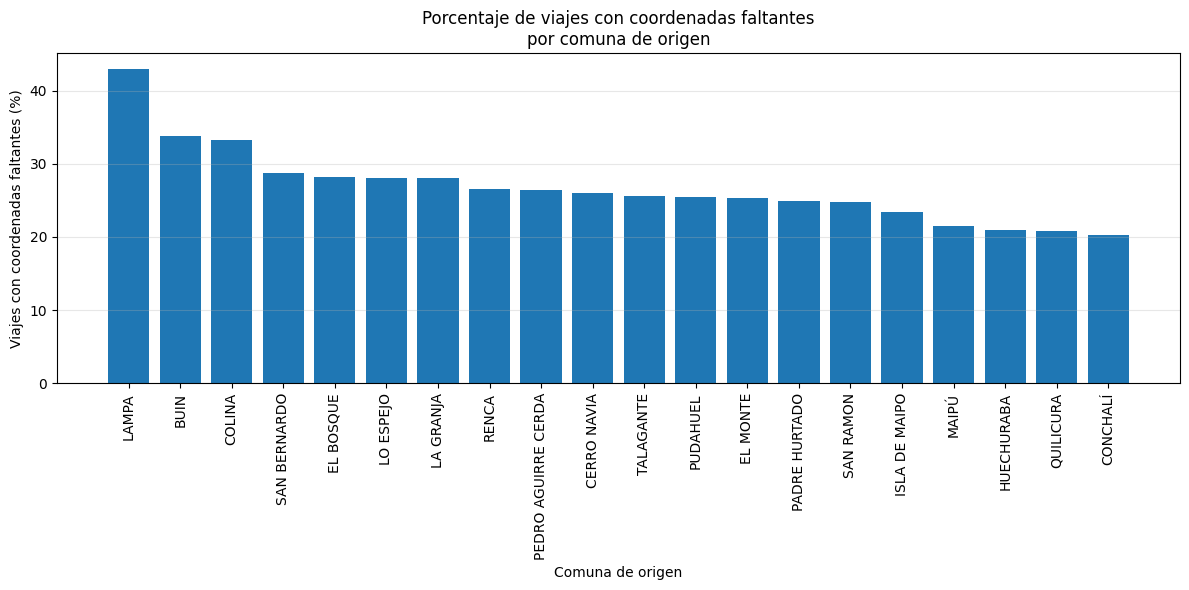

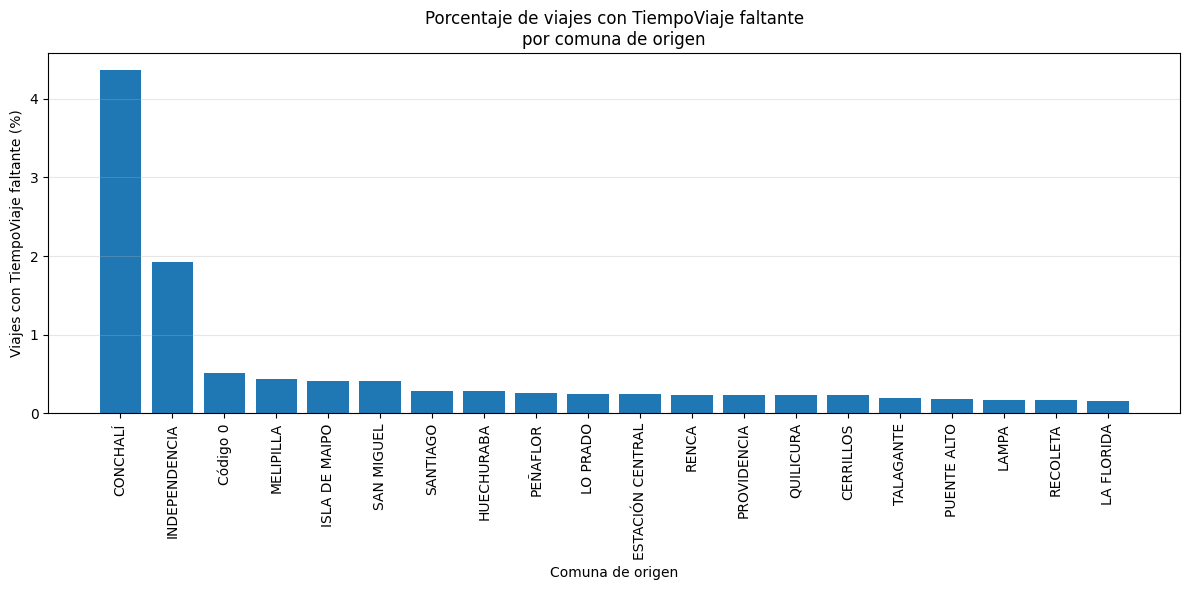

In [87]:
top = faltantes_comuna.sort_values(
    'pct_coord',
    ascending=False
).head(20)

plt.figure(figsize=(12, 6))

plt.bar(
    top['NombreComuna'],
    top['pct_coord']
)

plt.title(
    'Porcentaje de viajes con coordenadas faltantes\n'
    'por comuna de origen'
)
plt.xlabel('Comuna de origen')
plt.ylabel('Viajes con coordenadas faltantes (%)')
plt.xticks(rotation=90)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Primero crear la columna con el nombre para graficar
faltantes_comuna['NombreGrafico'] = (
    faltantes_comuna['NombreComuna']
    .fillna(
        'Código ' + faltantes_comuna['CodigoComuna'].astype(str)
    )
)

# Después crear el dataframe ordenado
faltantes_tiempo_comuna = (
    faltantes_comuna
    .sort_values('pct_tiempo', ascending=False)
    .head(20)
)

plt.figure(figsize=(12, 6))

plt.bar(
    faltantes_tiempo_comuna['NombreGrafico'],
    faltantes_tiempo_comuna['pct_tiempo']
)

plt.title(
    'Porcentaje de viajes con TiempoViaje faltante\n'
    'por comuna de origen'
)

plt.xlabel('Comuna de origen')
plt.ylabel('Viajes con TiempoViaje faltante (%)')
plt.xticks(rotation=90)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

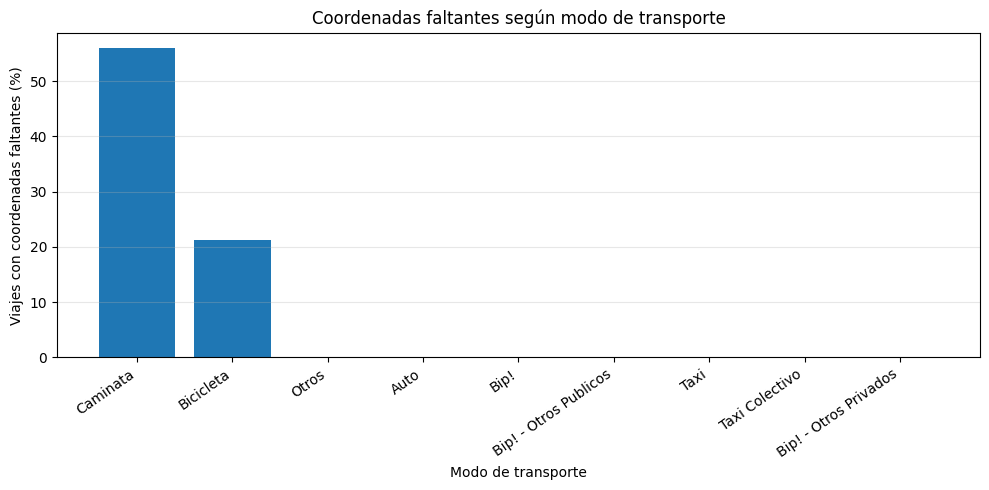

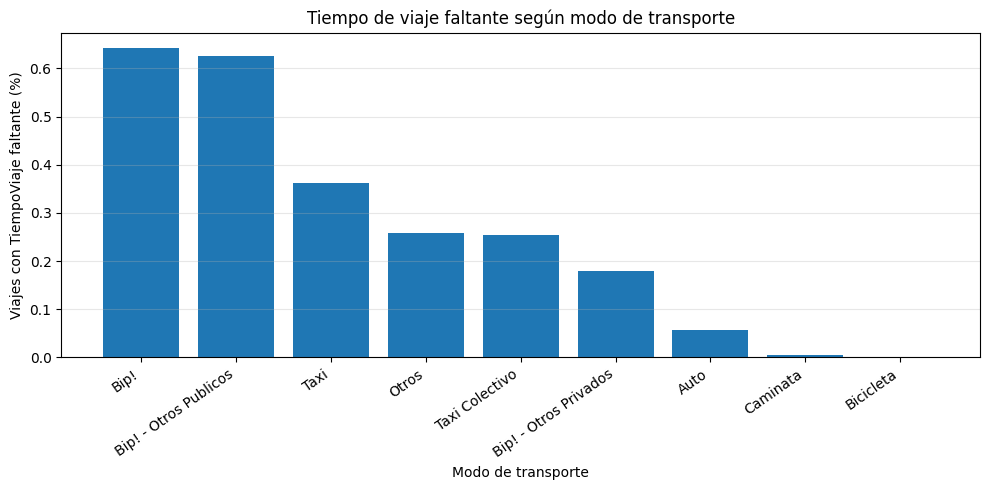

In [88]:
faltantes_modo = (
    viajes_nan.groupby('ModoDifusion')
    .agg(
        n=('ModoDifusion', 'size'),
        pct_coord=('NaN_Coordenadas', 'mean'),
        pct_tiempo=('NaN_Tiempo', 'mean')
    )
    .reset_index()
)

faltantes_modo['pct_coord'] *= 100
faltantes_modo['pct_tiempo'] *= 100

faltantes_modo['Modo'] = faltantes_modo['ModoDifusion'].map(dicc_modos)
df = faltantes_modo.sort_values('pct_coord', ascending=False)

plt.figure(figsize=(10, 5))

plt.bar(
    df['Modo'].fillna(df['ModoDifusion'].astype(str)),
    df['pct_coord']
)

plt.title('Coordenadas faltantes según modo de transporte')
plt.xlabel('Modo de transporte')
plt.ylabel('Viajes con coordenadas faltantes (%)')
plt.xticks(rotation=35, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

df = faltantes_modo.sort_values('pct_tiempo', ascending=False)

plt.figure(figsize=(10, 5))

plt.bar(
    df['Modo'].fillna(df['ModoDifusion'].astype(str)),
    df['pct_tiempo']
)

plt.title('Tiempo de viaje faltante según modo de transporte')
plt.xlabel('Modo de transporte')
plt.ylabel('Viajes con TiempoViaje faltante (%)')
plt.xticks(rotation=35, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretación:** En el caso de los IngresoHogar no hubo NaN que afectaran el valor de las medias, indicando que dichos datos estan completos; aunque sí hubo NaN en el en distintos tipos de Factor tanto en PERSONAS como en VIAJES, pero estos valores estan justificados ya que cada registro esa asociado a uno solo tipo de factor representando a que tipo de viaje esta asociado ese registro. La variable TiempoViaje de VIAJES tenia 278 NaN, clasiicandolo por comuna Conchalí tuvo la mayor cantidad con un 4% seguido por Independencia con un valor menor al 2%, las demas comunas tuvieron un valor menor al 1% lo cual representa una parte menor del total de datos.

Lo datos de las coordenadas tenian registrados 19741 NaN y al agruparlos por comunas los valores ausentes representaban entre un 20% y un 30%, pero el dato mas fuerte es que los modos de transporte que agrupan la mayoria de esta ausencia de valores son Caminata con mas del 50% y Bicicleta con un valor cercano al 20%, lo cual hace pensar que esta falta de valores en coordenadas hace referencia que las personas no saben exactamente los puntos de partida y llegada con medios de trasporte mas libres y recreativos que no necesariamente necesitan GPS para guiarse.

De las variables que identificamos con NaN las unicas que pueden afectar de alguna forma los retratos hechos anteriormente son las de Factores, pero la decision de separarlos de los analisis anteriores es la correcta, ya que al analizar los viajes durante semana el interes esta unicamente en los registros que tengan FactorLaboralNormal distinto de NaN; esa misma logica aplica para el analisis hecho con los viajes de fin de semana, el incluir registros que tengan NaN en FactorSabadoNormal o FactorDomingoNormal representan viajes que no se estan analizando en esa instancia.

### 10. Los extremos (8 pts)

**Instrucciones**

Busquen valores extremos o sospechosos en las duraciones (`TiempoViaje`) y en
las distancias de los viajes con origen en su comuna. La distancia está en
`DistanciaViaje.csv`, con llave `Viaje` y expresada en metros.

Cuantifíquenlos con algún criterio explícito: la regla de Tukey del boxplot, el
criterio de desviaciones estándar respecto de la media (por ejemplo, tres
sigmas), u otro que conozcan y justifiquen.

Investíguenlos: ¿son errores de registro o viajes reales posibles? Declaren la
decisión que tomaron (mantener, corregir o excluir) y muestren su efecto sobre
las medidas que reportaron, por ejemplo comparando la media y la mediana con y
sin ellos.

In [89]:
# Su código (agreguen las celdas que necesiten)
distanciaViajes = pd.read_csv(RUTA + "DistanciaViaje.csv", sep=";", decimal=",", low_memory=False)
distanciaViajesCompleto = pd.merge(viajes_lab, distanciaViajes, on="Viaje", how="left")
distanciaViajesCompletoMaipu = distanciaViajesCompleto[distanciaViajesCompleto['ComunaOrigen'] == 94]

In [90]:
# Duraciones válidas
tiempo_maipu = (
    distanciaViajesCompletoMaipu['TiempoViaje']
    .dropna()
)

# Distancias válidas:
# se eliminan los -1 porque no representan una distancia real
distancia_maipu = (
    distanciaViajesCompletoMaipu
    .loc[
        distanciaViajesCompletoMaipu['DistEuclidiana'] >= 0,
        'DistEuclidiana'
    ]
    .dropna()
)

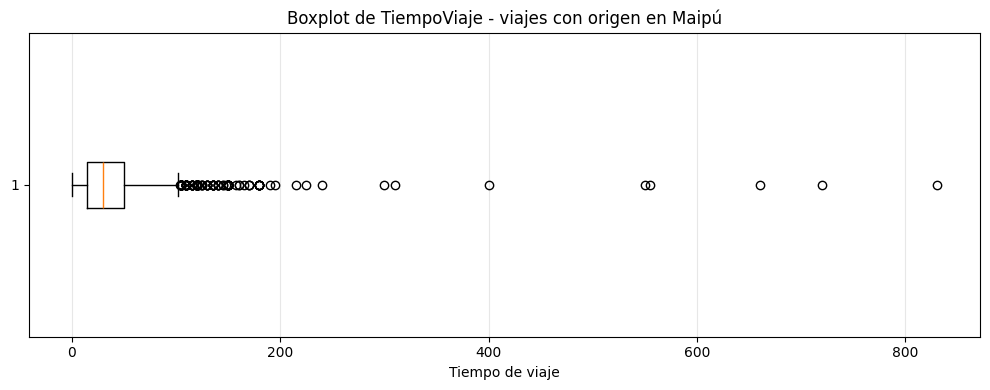

Q1: 15.0
Q3: 50.0
IQR: 35.0
Límite inferior: -37.5
Límite superior: 102.5
Cantidad de valores extremos: 214
Porcentaje ponderado de valores extremos: 3.6 %


In [91]:
factor_maipu = distanciaViajesCompletoMaipu.loc[tiempo_maipu.index, 'FactorLaboralNormal']

Q1_t, mediana_t, Q3_t = cuantil_ponderado(
    tiempo_maipu,
    factor_maipu,
    [0.25, 0.5, 0.75]
)

IQR_t = Q3_t - Q1_t

lim_inf_t = Q1_t - 1.5 * IQR_t
lim_sup_t = Q3_t + 1.5 * IQR_t

outliers_tiempo = tiempo_maipu[
    (tiempo_maipu < lim_inf_t) |
    (tiempo_maipu > lim_sup_t)
]

no_outliers_tiempo = tiempo_maipu[
    (tiempo_maipu >= lim_inf_t) &
    (tiempo_maipu <= lim_sup_t)
]

stats = [{
    'med': mediana_t,
    'q1': Q1_t,
    'q3': Q3_t,
    'whislo': no_outliers_tiempo.min(),
    'whishi': no_outliers_tiempo.max(),
    'fliers': outliers_tiempo.tolist()
}]

fig, ax = plt.subplots(figsize=(10, 4))

ax.bxp(
    stats,
    vert=False,
    showfliers=True
)

ax.set_title('Boxplot de TiempoViaje - viajes con origen en Maipú')
ax.set_xlabel('Tiempo de viaje')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

mask_outliers = (
    (tiempo_maipu < lim_inf_t) |
    (tiempo_maipu > lim_sup_t)
)

porcentaje_outliers = (
    factor_maipu[mask_outliers].sum()
    / factor_maipu.sum()
    * 100
)

print("Q1:", Q1_t)
print("Q3:", Q3_t)
print("IQR:", IQR_t)
print("Límite inferior:", lim_inf_t)
print("Límite superior:", lim_sup_t)
print("Cantidad de valores extremos:", len(outliers_tiempo))
print(
    "Porcentaje ponderado de valores extremos:",
    round(porcentaje_outliers, 2),
    "%"
)

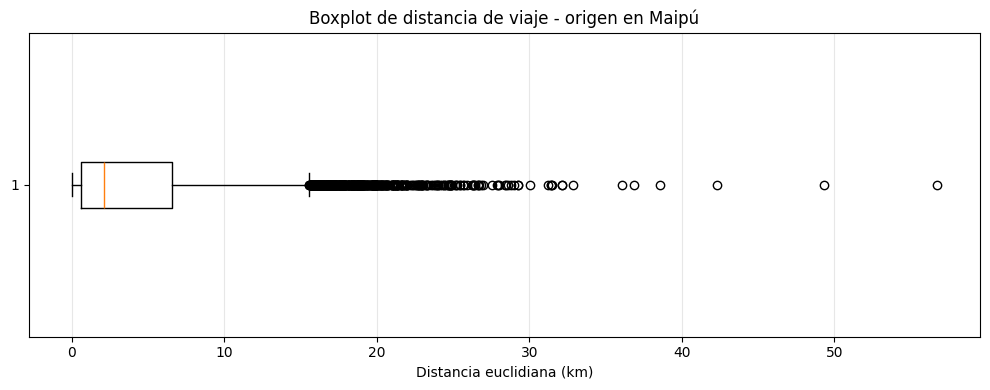

Q1: 587.0 m
Q3: 6578.0 m
IQR: 5991.0 m
Límite inferior: -8399.5 m
Límite superior: 15564.5 m
Cantidad de valores extremos: 482
Porcentaje ponderado de valores extremos: 8.49 %


In [92]:
factor_distancia_maipu = distanciaViajesCompletoMaipu.loc[distancia_maipu.index, 'FactorLaboralNormal']

Q1_d, mediana_d, Q3_d = cuantil_ponderado(
    distancia_maipu,
    factor_distancia_maipu,
    [0.25, 0.5, 0.75]
)

IQR_d = Q3_d - Q1_d

lim_inf_d = Q1_d - 1.5 * IQR_d
lim_sup_d = Q3_d + 1.5 * IQR_d

outliers_distancia = distancia_maipu[
    (distancia_maipu < lim_inf_d) |
    (distancia_maipu > lim_sup_d)
]

no_outliers_distancia = distancia_maipu[
    (distancia_maipu >= lim_inf_d) &
    (distancia_maipu <= lim_sup_d)
]

# Boxplot en kilómetros
stats = [{
    'med': mediana_d / 1000,
    'q1': Q1_d / 1000,
    'q3': Q3_d / 1000,
    'whislo': no_outliers_distancia.min() / 1000,
    'whishi': no_outliers_distancia.max() / 1000,
    'fliers': (outliers_distancia / 1000).tolist()
}]

fig, ax = plt.subplots(figsize=(10, 4))

ax.bxp(
    stats,
    vert=False,
    showfliers=True
)

ax.set_title('Boxplot de distancia de viaje - origen en Maipú')
ax.set_xlabel('Distancia euclidiana (km)')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

mask_outliers_d = (
    (distancia_maipu < lim_inf_d) |
    (distancia_maipu > lim_sup_d)
)

porcentaje_outliers_d = (
    factor_distancia_maipu[mask_outliers_d].sum()
    / factor_distancia_maipu.sum()
    * 100
)

print("Q1:", round(Q1_d, 2), "m")
print("Q3:", round(Q3_d, 2), "m")
print("IQR:", round(IQR_d, 2), "m")
print("Límite inferior:", round(lim_inf_d, 2), "m")
print("Límite superior:", round(lim_sup_d, 2), "m")
print("Cantidad de valores extremos:", len(outliers_distancia))
print(
    "Porcentaje ponderado de valores extremos:",
    round(porcentaje_outliers_d, 2),
    "%"
)

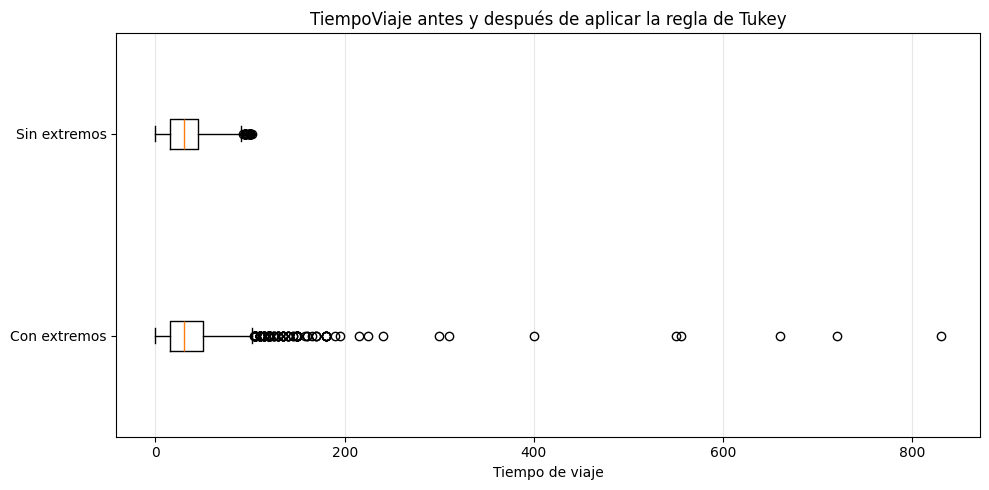

TIEMPO DE VIAJE
Media ponderada con extremos: 35.98668502916709
Media ponderada sin extremos: 31.948075690754457
Mediana ponderada con extremos: 30.0
Mediana ponderada sin extremos: 30.0


In [93]:
tiempo_sin_outliers = tiempo_maipu[
    (tiempo_maipu >= lim_inf_t) &
    (tiempo_maipu <= lim_sup_t)
]

factor_tiempo_sin_outliers = factor_maipu.loc[tiempo_sin_outliers.index]

# Cuantiles ponderados con extremos
Q1_con, mediana_con, Q3_con = cuantil_ponderado(
    tiempo_maipu,
    factor_maipu,
    [0.25, 0.5, 0.75]
)

IQR_con = Q3_con - Q1_con
lim_inf_con = Q1_con - 1.5 * IQR_con
lim_sup_con = Q3_con + 1.5 * IQR_con

no_outliers_con = tiempo_maipu[
    (tiempo_maipu >= lim_inf_con) &
    (tiempo_maipu <= lim_sup_con)
]

outliers_con = tiempo_maipu[
    (tiempo_maipu < lim_inf_con) |
    (tiempo_maipu > lim_sup_con)
]

# Cuantiles ponderados sin extremos
Q1_sin, mediana_sin, Q3_sin = cuantil_ponderado(
    tiempo_sin_outliers,
    factor_tiempo_sin_outliers,
    [0.25, 0.5, 0.75]
)

IQR_sin = Q3_sin - Q1_sin
lim_inf_sin = Q1_sin - 1.5 * IQR_sin
lim_sup_sin = Q3_sin + 1.5 * IQR_sin

no_outliers_sin = tiempo_sin_outliers[
    (tiempo_sin_outliers >= lim_inf_sin) &
    (tiempo_sin_outliers <= lim_sup_sin)
]

outliers_sin = tiempo_sin_outliers[
    (tiempo_sin_outliers < lim_inf_sin) |
    (tiempo_sin_outliers > lim_sup_sin)
]

stats = [
    {
        'label': 'Con extremos',
        'med': mediana_con,
        'q1': Q1_con,
        'q3': Q3_con,
        'whislo': no_outliers_con.min(),
        'whishi': no_outliers_con.max(),
        'fliers': outliers_con.tolist()
    },
    {
        'label': 'Sin extremos',
        'med': mediana_sin,
        'q1': Q1_sin,
        'q3': Q3_sin,
        'whislo': no_outliers_sin.min(),
        'whishi': no_outliers_sin.max(),
        'fliers': outliers_sin.tolist()
    }
]

fig, ax = plt.subplots(figsize=(10, 5))

ax.bxp(
    stats,
    vert=False,
    showfliers=True
)

ax.set_title('TiempoViaje antes y después de aplicar la regla de Tukey')
ax.set_xlabel('Tiempo de viaje')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Medias ponderadas
media_con = np.average(
    tiempo_maipu,
    weights=factor_maipu
)

media_sin = np.average(
    tiempo_sin_outliers,
    weights=factor_tiempo_sin_outliers
)

print("TIEMPO DE VIAJE")
print("Media ponderada con extremos:", media_con)
print("Media ponderada sin extremos:", media_sin)
print("Mediana ponderada con extremos:", mediana_con)
print("Mediana ponderada sin extremos:", mediana_sin)

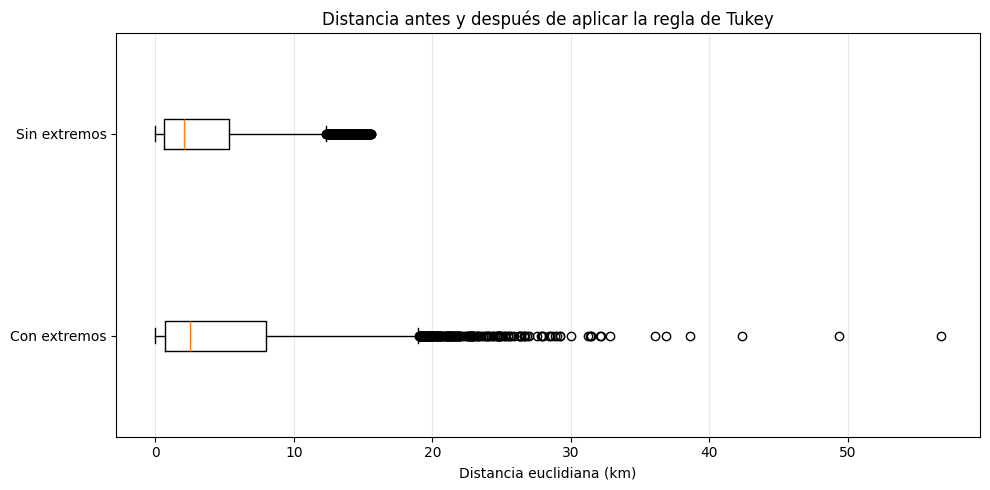

DISTANCIA
Media con extremos (km): 5.238597346859149
Media sin extremos (km): 3.738738587424634
Mediana con extremos (km): 2.5225
Mediana sin extremos (km): 2.0735


In [94]:
distancia_sin_outliers = distancia_maipu[
    (distancia_maipu >= lim_inf_d) &
    (distancia_maipu <= lim_sup_d)
]


plt.figure(figsize=(10, 5))

plt.boxplot(
    [
        distancia_maipu / 1000,
        distancia_sin_outliers / 1000
    ],
    tick_labels=['Con extremos', 'Sin extremos'],
    vert=False
)

plt.title('Distancia antes y después de aplicar la regla de Tukey')
plt.xlabel('Distancia euclidiana (km)')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


print("DISTANCIA")
print("Media con extremos (km):", distancia_maipu.mean() / 1000)
print("Media sin extremos (km):", distancia_sin_outliers.mean() / 1000)
print("Mediana con extremos (km):", distancia_maipu.median() / 1000)
print("Mediana sin extremos (km):", distancia_sin_outliers.median() / 1000)

Investíguenlos: ¿son errores de registro o viajes reales posibles? Declaren la
decisión que tomaron (mantener, corregir o excluir) y muestren su efecto sobre
las medidas que reportaron, por ejemplo comparando la media y la mediana con y
sin ellos.

**Interpretación:** Los datos que estan por sobre el bigote superior se consideran viajes reales y tiempos de duracion validos, esto debido a que considerando la gran cantidad de datos resgistrados es razonable pensar que existen esas mediciones teniendo en consideracion la probabilidad de la distribucion de datos. Aun asi, si se sacan esos datos como errores y se vuelve a calcular las medias y medianas, estos valores no sufren cambios significativos por lo que se prefiere conservar la informacion antes que eliminarla en este caso puntual.

### 11. Una transformación (9 pts)

**Instrucciones**

Apliquen una transformación justificada a una variable de su retrato, por
ejemplo el logaritmo al ingreso o a la duración.

Muestren el efecto con un gráfico del antes y el después.

En la interpretación, expliquen cómo cambia la forma de la distribución y qué
medidas se vuelven más o menos informativas después de la transformación.

In [ ]:
# Su código (agreguen las celdas que necesiten)
tiempo_original = (
    distanciaViajesCompletoMaipu['TiempoViaje']
    .dropna()
)
tiempo_log = np.log1p(tiempo_original)


Cantidad de observaciones: 5284
Valores negativos: 0
Valores iguales a 0: 9


In [ ]:
tiempo_log = np.log1p(tiempo_original)

tiempo_log.head()

0    4.262680
1    4.663439
3    4.025352
5    3.433987
6    2.397895
Name: TiempoViaje, dtype: float64

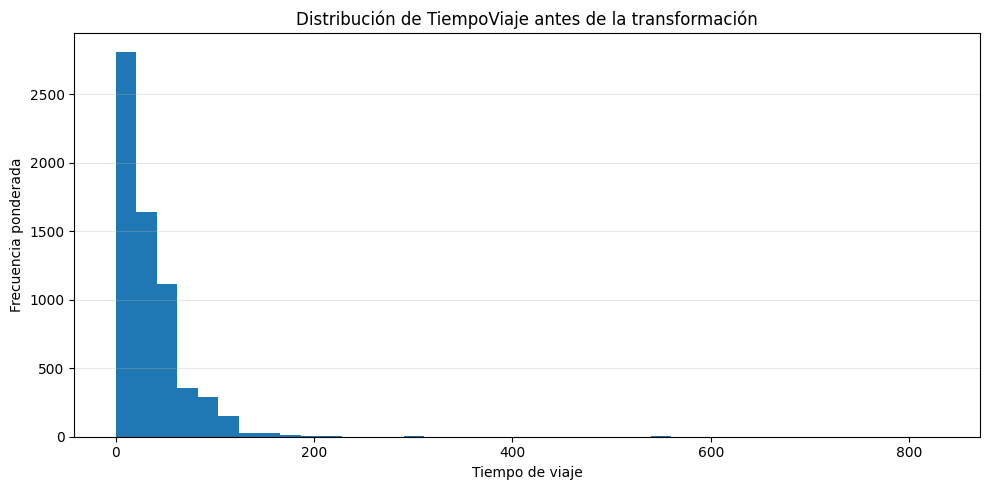

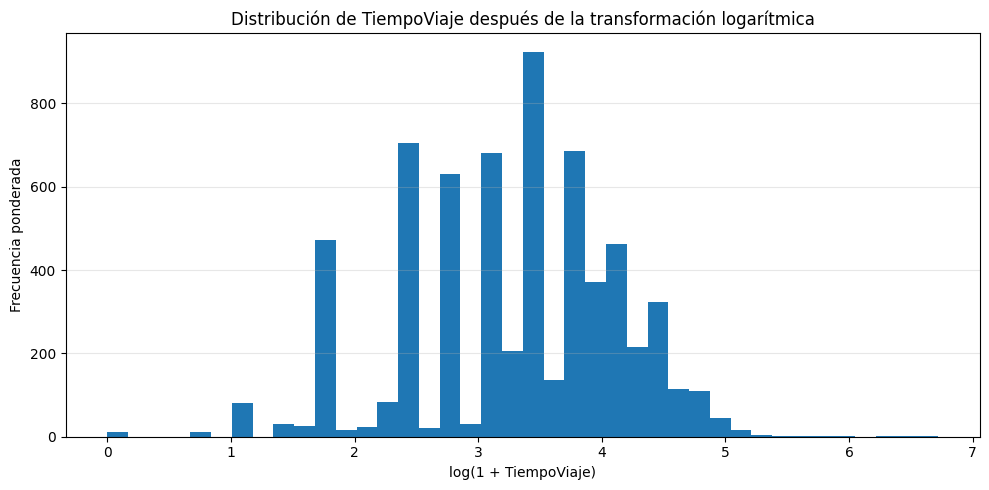

In [101]:
factor_tiempo_original = distanciaViajesCompletoMaipu.loc[tiempo_original.index, 'FactorLaboralNormal']
factor_tiempo_log = distanciaViajesCompletoMaipu.loc[tiempo_log.index, 'FactorLaboralNormal']

plt.figure(figsize=(10, 5))

plt.hist(
    tiempo_original,
    bins=40,
    weights=factor_tiempo_original
)

plt.title('Distribución de TiempoViaje antes de la transformación')
plt.xlabel('Tiempo de viaje')
plt.ylabel('Frecuencia ponderada')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()


plt.figure(figsize=(10, 5))

plt.hist(
    tiempo_log,
    bins=40,
    weights=factor_tiempo_log
)

plt.title('Distribución de TiempoViaje después de la transformación logarítmica')
plt.xlabel('log(1 + TiempoViaje)')
plt.ylabel('Frecuencia ponderada')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()

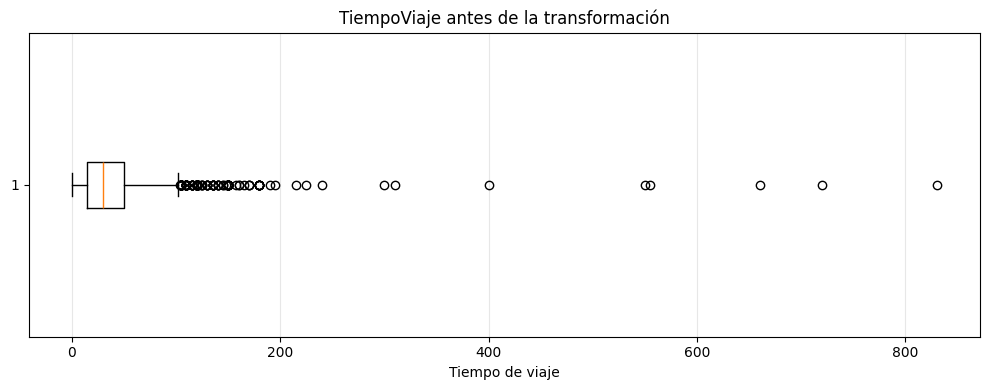

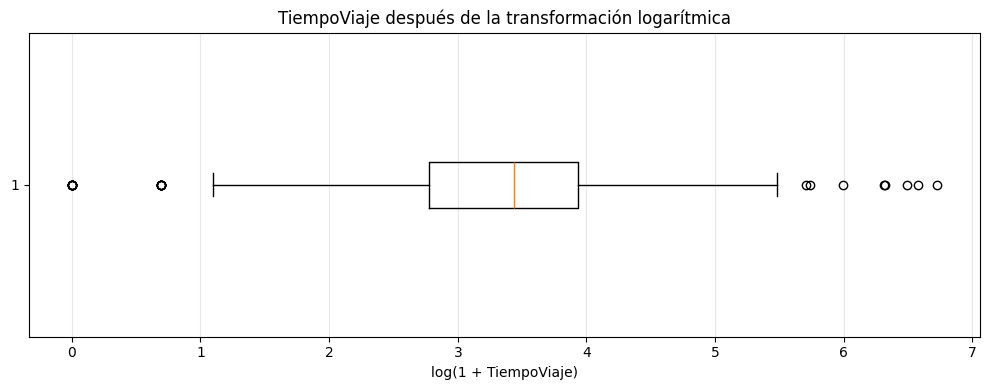

In [102]:
# -----------------------------
# Boxplot ponderado: original
# -----------------------------

Q1_orig, mediana_orig, Q3_orig = cuantil_ponderado(
    tiempo_original,
    factor_tiempo_original,
    [0.25, 0.5, 0.75]
)

IQR_orig = Q3_orig - Q1_orig

lim_inf_orig = Q1_orig - 1.5 * IQR_orig
lim_sup_orig = Q3_orig + 1.5 * IQR_orig

outliers_orig = tiempo_original[
    (tiempo_original < lim_inf_orig) |
    (tiempo_original > lim_sup_orig)
]

no_outliers_orig = tiempo_original[
    (tiempo_original >= lim_inf_orig) &
    (tiempo_original <= lim_sup_orig)
]

stats_orig = [{
    'med': mediana_orig,
    'q1': Q1_orig,
    'q3': Q3_orig,
    'whislo': no_outliers_orig.min(),
    'whishi': no_outliers_orig.max(),
    'fliers': outliers_orig.tolist()
}]

fig, ax = plt.subplots(figsize=(10, 4))

ax.bxp(
    stats_orig,
    vert=False,
    showfliers=True
)

ax.set_title('TiempoViaje antes de la transformación')
ax.set_xlabel('Tiempo de viaje')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


# -----------------------------
# Boxplot ponderado: log
# -----------------------------

Q1_log, mediana_log, Q3_log = cuantil_ponderado(
    tiempo_log,
    factor_tiempo_log,
    [0.25, 0.5, 0.75]
)

IQR_log = Q3_log - Q1_log

lim_inf_log = Q1_log - 1.5 * IQR_log
lim_sup_log = Q3_log + 1.5 * IQR_log

outliers_log = tiempo_log[
    (tiempo_log < lim_inf_log) |
    (tiempo_log > lim_sup_log)
]

no_outliers_log = tiempo_log[
    (tiempo_log >= lim_inf_log) &
    (tiempo_log <= lim_sup_log)
]

stats_log = [{
    'med': mediana_log,
    'q1': Q1_log,
    'q3': Q3_log,
    'whislo': no_outliers_log.min(),
    'whishi': no_outliers_log.max(),
    'fliers': outliers_log.tolist()
}]

fig, ax = plt.subplots(figsize=(10, 4))

ax.bxp(
    stats_log,
    vert=False,
    showfliers=True
)

ax.set_title('TiempoViaje después de la transformación logarítmica')
ax.set_xlabel('log(1 + TiempoViaje)')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [103]:
# Asimetría ponderada
def asimetria_ponderada(valores, pesos):
    media = np.average(valores, weights=pesos)

    m2 = np.average(
        (valores - media) ** 2,
        weights=pesos
    )

    m3 = np.average(
        (valores - media) ** 3,
        weights=pesos
    )

    return m3 / (m2 ** 1.5)


# Medias ponderadas
media_original = np.average(
    tiempo_original,
    weights=factor_tiempo_original
)

media_log = np.average(
    tiempo_log,
    weights=factor_tiempo_log
)


# Medianas ponderadas
mediana_original = cuantil_ponderado(
    tiempo_original,
    factor_tiempo_original,
    [0.5]
)[0]

mediana_log = cuantil_ponderado(
    tiempo_log,
    factor_tiempo_log,
    [0.5]
)[0]


# Asimetrías ponderadas
asimetria_original = asimetria_ponderada(
    tiempo_original,
    factor_tiempo_original
)

asimetria_log = asimetria_ponderada(
    tiempo_log,
    factor_tiempo_log
)


print("ASIMETRÍA")
print("Antes:", round(asimetria_original, 3))
print("Después:", round(asimetria_log, 3))

print("\nMEDIA Y MEDIANA")
print("Media original:", round(media_original, 2))
print("Mediana original:", round(mediana_original, 2))

print("\nEn escala logarítmica:")
print("Media:", round(media_log, 3))
print("Mediana:", round(mediana_log, 3))

ASIMETRÍA
Antes: 6.632
Después: -0.313

MEDIA Y MEDIANA
Media original: 35.99
Mediana original: 30.0

En escala logarítmica:
Media: 3.266
Mediana: 3.434


In [104]:
media_original = np.average(
    tiempo_original,
    weights=factor_tiempo_original
)

media_log = np.average(
    tiempo_log,
    weights=factor_tiempo_log
)

media_log_retransformada = np.expm1(media_log)

mediana_original = cuantil_ponderado(
    tiempo_original,
    factor_tiempo_original,
    [0.5]
)[0]

print(
    "Media aritmética original:",
    round(media_original, 2)
)

print(
    "Media logarítmica retransformada:",
    round(media_log_retransformada, 2)
)

print(
    "Mediana original:",
    round(mediana_original, 2)
)

Media aritmética original: 35.99
Media logarítmica retransformada: 25.22
Mediana original: 30.0


**Interpretación:** Se realizó una trasformada de log(1 + TiempoViaje) de los viajes desde Maipú debido a que el logaritmo permite dismiuir mucho los datos grandes y no disminuir tanto los datos pequeños y ademas evita problemas con los tiempos de viaje iguales a 0, permitiendo acotar en gran medida los datos excesivamente grandes sin perder el orden de los datos. Al aplicar la transformada se puede apreciar en los histogramas que se pasa de tener una carga casi total de los datos a la izquierda a una distribucion mucho mas equilibrada, pasando de un valor de asimetria de 6.077 a -0.36, lo cual permite trabajar con un conjunto de datos que no estan siendo influenciados unos pocos datos con valores excesivanente grandes.

En el caso del boxplot con la transformada, muestra los datos de forma mucho mas compacta al igual el histograma y ademas permite identificar valores atipicos que no se pudieron apreciar con los valores en la escala original dado que todas las metricas anteriores fueron afectadas por los valores grandes y permitiendo ser considerados para distintos analisis.

Por ultimo, la media retransformada de escala normal a logaritmica y de vuelta muestra un valor de 36.62 a 25.54, este 2do valor se asemeja a un promedio geometrico, donde los valores muy altos en comparacion de los demas valores no afectan en tanta proporcion como una media aritmetica.

## Parte 4. Síntesis (20 puntos)

### 12. El retrato (8 pts)

En el día laboral normal de 2012, la muestra de Maipú representa 153.246 hogares y 516.375 personas.
Su población es levemente más joven que la ciudad: P25, mediana y P75 de 19, 34 y 53 años, frente a 19, 35 y 54.
Las mujeres representan el 52,5% de la población comunal, algo más que el 51,5% del Gran Santiago.

El ingreso mediano ponderado es $500.000, inferior al de la ciudad ($520.000), y su media ($595.384) también está bajo la capital ($729.898).
La distancia entre media y mediana evidencia una cola de ingresos altos; la media truncada de Maipú es $533.286.

La antigüedad mediana de los vehículos corresponde al tramo de 6 a 10 años, igual que en la ciudad.
Sin embargo, solo el 18,9% del parque vehicular comunal tiene sello verde, frente al 25,1% metropolitano.

En movilidad, el 67,1% de los viajes originados en Maipú permanece dentro de la comuna; caminar concentra 35,6% y el transporte público 33,2%.
Ñuñoa contrasta con Maipú al retener solo 41,5% de sus viajes, mostrando una movilidad más conectada con otras comunas.

### 13. ¿De quién hablan sus números? (6 pts)

Las cifras no describen solo a quienes respondieron: al ponderarlas, estiman hogares, personas y viajes de Maipú y del Gran Santiago cubiertos por la Encuesta Origen-Destino 2012. Los indicadores de composición y movilidad representan específicamente un día laboral de temporada normal, pues usan `Factor_LaboralNormal` y `FactorLaboralNormal`; los indicadores de hogares y vehículos usan `Factor`. Por ello, quedan fuera de esos resultados laborales los viajes y personas observados en fines de semana o temporada estival, además de viajes sin factor válido para ese universo. El retrato tampoco es un censo: puede subrepresentar a personas fuera de los hogares encuestados, a quienes no respondieron y a viajes con errores de recuerdo o coordenadas faltantes, especialmente en caminata y bicicleta.

### 14. Una hipótesis para más adelante (6 pts)

**Instrucciones**

- Formulen una hipótesis **verificable** que su exploración sugiere pero no
  demuestra (por ejemplo, sobre la relación entre dos variables de su comuna).
- Se evalúa que sea precisa, comprobable y motivada por sus datos. 



**Hipótesis.** Dentro de Maipú, los hogares de mayores ingresos realizan una proporción mayor de viajes en automóvil y menor en transporte público que los hogares de menores ingresos. El contraste observado entre Maipú y Ñuñoa motiva esta hipótesis, pero no demuestra que la misma relación exista entre hogares de una misma comuna.

**Cómo verificarla.** Unir viajes, personas y hogares mediante sus identificadores, seleccionando los hogares residentes en Maipú y los viajes del universo laboral de temporada normal. Clasificar los hogares en quintiles de ingreso utilizando el factor de expansión de hogares (`Factor`) y asignar cada viaje al quintil de su hogar. Luego, calcular el reparto modal de cada quintil ponderando los viajes con `FactorLaboralNormal`, manteniendo la definición de transporte público utilizada anteriormente. La hipótesis recibiría apoyo si la participación del automóvil aumenta y la del transporte público disminuye al pasar de los quintiles de menores ingresos a los de mayores ingresos. Esta comparación mostraría una asociación, sin demostrar por sí sola una relación causal.

## Declaración de uso de IA generativa

Se usó chatgtp principalmente para la generacion del codigo de los graficos, ademas de identificar ciertos metodos y errores de ejeucion.

## Antes de entregar

- [ ] El notebook corre de principio a fin sin errores.
- [ ] `MI_COMUNA` y `COMUNA_CONTRASTE` están definidas.
- [ ] Toda cifra poblacional está ponderada y su universo está declarado.
- [ ] Todos los gráficos tienen título y ejes rotulados con unidades.
- [ ] Todas las celdas de "Interpretación" están completas.
- [ ] El archivo se llama `tarea1_apellido1_apellido2.ipynb`.
- [ ] La declaración de uso de IA está completa.